<a href="https://colab.research.google.com/github/bri-4nn/cdmx-airbnb-data-analysis/blob/main/notebooks/cdmx_airbnb_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Limpieza y Transformación de Datos (Data Wrangling)**


In [59]:
import pandas as pd
import numpy as np

# Cargar archivo CSV.
df = pd.read_csv('listings.csv')

# Primeras filas del DataFrame
df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1698274831948209016,https://www.airbnb.com/rooms/1698274831948209016,20260615212254,2026-06-16,city scrape,Roma Residence | Luxury Suite 305,"Discover Condesa Residence Luxury Suites, excl...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,471105419,...,NaN,NaN,NaN,NaN,NaN,42,42,0,0,NaN
1,1120444645818769896,https://www.airbnb.com/rooms/1120444645818769896,20260615212254,2026-06-17,city scrape,Grande y bonita habitación con cocina y baño,Disconnect from your worries in this spacious ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,548898239,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
2,1414477907775396874,https://www.airbnb.com/rooms/1414477907775396874,20260615212254,2026-06-17,city scrape,Ven a sentirte como en casa.,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,49281983,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN
3,1298027147444763745,https://www.airbnb.com/rooms/1298027147444763745,20260615212254,2026-06-17,city scrape,Habitación pequeña 16,You'll be close to everything if you stay in t...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,368484187,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN
4,1680714857095865427,https://www.airbnb.com/rooms/1680714857095865427,20260615212254,2026-06-16,city scrape,Quadruple Suite with Bathroom,Quad Suite – 1 Bathroom<br />Sleeps up to 4 gu...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1680682785801540826,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN


In [61]:
relevant_columns = [
    'id', 'name', 'host_id', 'host_is_superhost', 'host_listings_count',
    'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
    'accommodates', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'maximum_nights', 'number_of_reviews',
    'review_scores_rating', 'availability_365'
]

# Filtrar el DataFrame para mantener solo las columnas relevantes
df_filtered = df[[col for col in relevant_columns if col in df.columns]].copy()

# Mostrar las primeras filas del DataFrame filtrado
display(df_filtered.head())
df_filtered.info()

,id,name,host_id,host_is_superhost,host_listings_count,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bedrooms,beds,price,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,availability_365
0,1698274831948209016,Roma Residence | Luxury Suite 305,471105419,t,42.0,Cuauhtémoc,19.406572,-99.163091,Entire home/apt,4,1.0,1.0,"$2,066.00",1.0,365.0,0,NaN,365
1,1120444645818769896,Grande y bonita habitación con cocina y baño,548898239,f,1.0,Benito Juárez,19.394448,-99.163367,Entire home/apt,2,1.0,1.0,$628.00,1.0,365.0,0,NaN,257
2,1414477907775396874,Ven a sentirte como en casa.,49281983,f,2.0,Coyoacán,19.339362,-99.185070,Private room,2,NaN,2.0,$499.00,1.0,365.0,0,NaN,158
3,1298027147444763745,Habitación pequeña 16,368484187,f,2.0,Miguel Hidalgo,19.461230,-99.190020,Private room,1,1.0,1.0,"$2,511.00",1.0,365.0,0,NaN,365
4,1680714857095865427,Quadruple Suite with Bathroom,1680682785801540826,f,2.0,Cuauhtémoc,19.420992,-99.157935,Private room,4,2.0,3.0,"$8,263.24",1.0,1125.0,0,NaN,365


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31430 entries, 0 to 31429
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      31430 non-null  int64  
 1   name                    31430 non-null  object 
 2   host_id                 31430 non-null  int64  
 3   host_is_superhost       31425 non-null  object 
 4   host_listings_count     31425 non-null  float64
 5   neighbourhood_cleansed  31430 non-null  object 
 6   latitude                31430 non-null  float64
 7   longitude               31430 non-null  float64
 8   room_type               31430 non-null  object 
 9   accommodates            31430 non-null  int64  
 10  bedrooms                26092 non-null  float64
 11  beds                    29137 non-null  float64
 12  price                   29637 non-null  object 
 13  minimum_nights          31419 non-null  float64
 14  maximum_nights          31419 non-null

In [65]:
# Eliminar '$' y ',' de la columna 'price' y convertir a float
df_filtered['price'] = df_filtered['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_filtered['price'] = pd.to_numeric(df_filtered['price'], errors='coerce')

# Verificar los cambios
display(df_filtered[['price']].head())
df_filtered.info()

,price
0,2066.00
1,628.00
2,499.00
3,2511.00
4,8263.24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31430 entries, 0 to 31429
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      31430 non-null  int64  
 1   name                    31430 non-null  object 
 2   host_id                 31430 non-null  int64  
 3   host_is_superhost       31425 non-null  object 
 4   host_listings_count     31425 non-null  float64
 5   neighbourhood_cleansed  31430 non-null  object 
 6   latitude                31430 non-null  float64
 7   longitude               31430 non-null  float64
 8   room_type               31430 non-null  object 
 9   accommodates            31430 non-null  int64  
 10  bedrooms                26092 non-null  float64
 11  beds                    29137 non-null  float64
 12  price                   29637 non-null  float64
 13  minimum_nights          31419 non-null  float64
 14  maximum_nights          31419 non-null

In [66]:
# Convertir valores nulos o cadenas ('t'/'f') en valores booleanos o legibles (True/False o 'Si'/ 'No').
df_filtered['host_is_superhost'] = df_filtered['host_is_superhost'].replace({'t': 'Si', 'f': 'No'})

# Verificar los cambios
display(df_filtered[['host_is_superhost']].head())

,host_is_superhost
0,Si
1,No
2,No
3,No
4,No


In [67]:
# Antes de filtrar, veamos la distribución de precios
print("Estadísticas de precios antes de filtrar outliers:")
display(df_filtered['price'].describe())

# Establecer límites para los outliers usando percentiles
lower_bound = df_filtered['price'].quantile(0.01)
upper_bound = df_filtered['price'].quantile(0.99)

print(f"\nPrecio mínimo permitido (1er percentil): {lower_bound:.2f}")
print(f"Precio máximo permitido (99no percentil): {upper_bound:.2f}")

# Filtrar los ratings nulos del precio
df_filtered = df_filtered[(df_filtered['price'] >= lower_bound) & (df_filtered['price'] <= upper_bound)].dropna(subset=['review_scores_rating'])

# Verificar los cambios
print("\nEstadísticas de precios después de filtrar outliers:")
display(df_filtered['price'].describe())
print(f"\nNúmero de filas después de filtrar outliers: {len(df_filtered)}")

Estadísticas de precios antes de filtrar outliers:


,price
count,2.963700e+04
mean,2.913694e+03
std,9.398892e+03
min,1.876000e+01
25%,1.073000e+03
50%,1.756000e+03
75%,2.853000e+03
max,1.141520e+06



Precio mínimo permitido (1er percentil): 337.79
Precio máximo permitido (99no percentil): 20292.43

Estadísticas de precios después de filtrar outliers:


,price
count,24251.000000
mean,2305.751395
std,2102.727827
min,339.000000
25%,1084.500000
50%,1717.540000
75%,2735.880000
max,20222.920000



Número de filas después de filtrar outliers: 24251


# **Análisis Exploratorio y Validación de Hipótesis (EDA)**

**H1 (Estancias mínimas vs Ocupación):**



In [68]:
# Se crea una variable agrupada para las noches mínimas

bins = [0, 2, 6, float('inf')]
labels = ['1-2 noches', '3-6 noches', '7+ noches']

df_filtered['min_nights_group'] = pd.cut(df_filtered['minimum_nights'], bins=bins, labels=labels)

display(df_filtered[['minimum_nights', 'min_nights_group']])

,minimum_nights,min_nights_group
5,1.0,1-2 noches
6,1.0,1-2 noches
9,2.0,1-2 noches
12,4.0,3-6 noches
15,1.0,1-2 noches
...,...,...
31402,1.0,1-2 noches
31408,28.0,7+ noches
31417,4.0,3-6 noches
31422,1.0,1-2 noches


In [69]:
# Calcular el promedio de 'availability_365' y 'number_of_reviews' por 'min_nights_group'
occupancy_analysis = df_filtered.groupby('min_nights_group').agg(
    avg_availability_365=('availability_365', 'mean'),
    avg_number_of_reviews=('number_of_reviews', 'mean')
).reset_index()

# Mostrar los resultados
print("Promedio de Disponibilidad y Número de Reseñas por Grupo de Noches Mínimas:")
display(occupancy_analysis)

Promedio de Disponibilidad y Número de Reseñas por Grupo de Noches Mínimas:


/tmp/ipykernel_1795/3473785584.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  occupancy_analysis = df_filtered.groupby('min_nights_group').agg(


,min_nights_group,avg_availability_365,avg_number_of_reviews
0,1-2 noches,261.883670,72.230378
1,3-6 noches,220.535943,46.069627
2,7+ noches,226.968978,23.224453


**H2 (Precio vs Ratings por zona):**

In [70]:
# Correlaciones precio vs rating por alcaldía

corr_alc = round(df_filtered.groupby('neighbourhood_cleansed')['review_scores_rating'].corr(df_filtered['price']), 2)
display(corr_alc)

# Clasificar Alcaldías por Nivel de Demanda/Volumen (Top vs Periferia)
top_zones = df_filtered['neighbourhood_cleansed'].value_counts().head(5).index.tolist()
df_filtered['zona_grupo'] = df_filtered['neighbourhood_cleansed'].apply(
    lambda x: 'Top 5 Zonas Populares' if x in top_zones else 'Otras Zonas'
)

# Cálculo de Correlaciones por Grupo
print("=== CORRELACIÓN ENTRE RATING Y PRECIO ===")
for grupo in df_filtered['zona_grupo'].unique():
    subset = df_filtered[df_filtered['zona_grupo'] == grupo]
    corr = subset['review_scores_rating'].corr(subset['price'])
    print(f"• {grupo}: Correlación de Pearson = {corr:.4f}")

,review_scores_rating
neighbourhood_cleansed,
Azcapotzalco,-0.12
Benito Juárez,0.04
Coyoacán,0.03
Cuajimalpa de Morelos,-0.05
Cuauhtémoc,0.10
Gustavo A. Madero,0.12
Iztacalco,0.08
Iztapalapa,0.08
La Magdalena Contreras,0.10


=== CORRELACIÓN ENTRE RATING Y PRECIO ===
• Top 5 Zonas Populares: Correlación de Pearson = 0.0788
• Otras Zonas: Correlación de Pearson = 0.0172


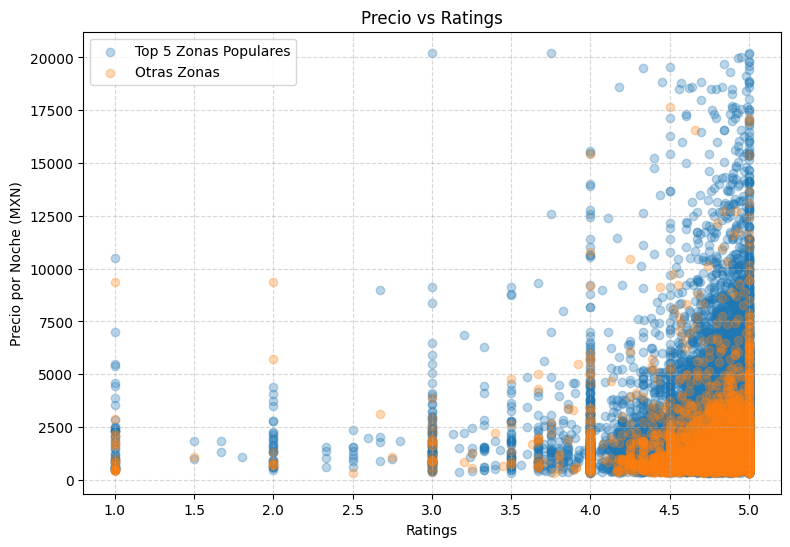

In [72]:
# Importamos la bibliotecas
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar correlaciones

fig, ax = plt.subplots(figsize=(9, 6))

for zona in df_filtered['zona_grupo'].unique():
    ax.scatter(
        x = df_filtered[df_filtered['zona_grupo'] == zona]['review_scores_rating'],
        y = df_filtered[df_filtered['zona_grupo'] == zona]['price'],
        label = zona,
        alpha = 0.3) # Ajustar el valor de alpha para mayor transparencia

ax.set_title('Precio vs Ratings')
ax.set_xlabel('Ratings')
ax.set_ylabel('Precio por Noche (MXN)')
ax.legend(loc = 'upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**H3 (Superhosts vs Anfitriones Estándar):**

In [73]:
# Mapear y estandarizar la variable 'host_is_superhost' ('t' -> 'Superhost', 'f' -> 'Estándar')
df_filtered['superhost_flag'] = df_filtered['host_is_superhost'].map({'Si': 'Superhost', 'No': 'Estándar'}).fillna('Estándar')

# Resumen Estadístico por Categoría de Anfitrión
resumen_host = df_filtered.groupby('superhost_flag').agg(
    total_alojamientos=('id', 'count'),
    precio_promedio=('price', 'mean'),
    precio_mediana=('price', 'median'),
    disponibilidad_promedio=('availability_365', 'mean'),
    reviews_promedio=('number_of_reviews', 'mean'),
    rating_promedio=('review_scores_rating', 'mean')
).reset_index()

print("=== RESUMEN COMPARATIVO: SUPERHOST VS ESTÁNDAR ===")
print(resumen_host.round(2))



=== RESUMEN COMPARATIVO: SUPERHOST VS ESTÁNDAR ===
  superhost_flag  total_alojamientos  precio_promedio  precio_mediana  \
0       Estándar               12887          2149.30          1597.0   
1      Superhost               11364          2483.17          1883.0   

   disponibilidad_promedio  reviews_promedio  rating_promedio  
0                   260.25             52.51             4.67  
1                   252.13             86.20             4.86  


/tmp/ipykernel_1795/1935091238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1795/1935091238.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


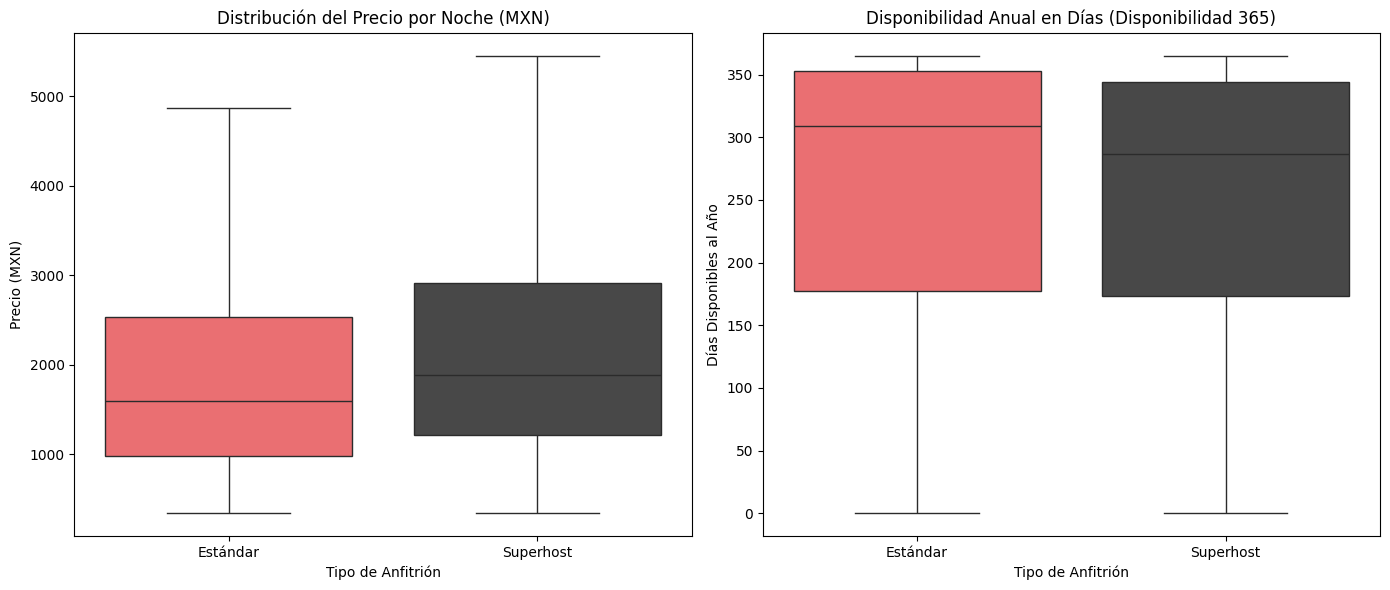

In [74]:
# Visualización: Boxplots Comparativos de Precio y Disponibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Comparación de Precios
sns.boxplot(
    ax=axes[0], data=df_filtered, x='superhost_flag', y='price',
    palette=['#FF5A5F', '#484848'], showfliers=False
)
axes[0].set_title('Distribución del Precio por Noche (MXN)')
axes[0].set_xlabel('Tipo de Anfitrión')
axes[0].set_ylabel('Precio (MXN)')

# Gráfico B: Comparación de Disponibilidad Anual (Menor disponibilidad = Mayor Ocupación)
sns.boxplot(
    ax=axes[1], data=df_filtered, x='superhost_flag', y='availability_365',
    palette=['#FF5A5F', '#484848'], showfliers=False
)
axes[1].set_title('Disponibilidad Anual en Días (Disponibilidad 365)')
axes[1].set_xlabel('Tipo de Anfitrión')
axes[1].set_ylabel('Días Disponibles al Año')

plt.tight_layout()
plt.show()

**Preguntas de negocio**

In [75]:
# 1. Precio promedio por alcaldía y tipo de alojamiento
p1 = df_filtered.groupby(['neighbourhood_cleansed', 'room_type'])['price'].agg(['mean', 'median', 'count']).reset_index()
print("=== 1. PRECIO PROMEDIO POR ZONA Y CATEGORÍA ===")
print(p1)

# 2. Correlación entre reseñas recientes y precio
# Usamos 'number_of_reviews_ltm' (reseñas en los últimos 12 meses) si está disponible, o 'number_of_reviews'
col_reviews = 'number_of_reviews_ltm' if 'number_of_reviews_ltm' in df_filtered.columns else 'number_of_reviews'
corr_recent = df_filtered['price'].corr(df_filtered[col_reviews])
print(f"\n=== 2. CORRELACIÓN PRECIO VS RESEÑAS RECIENTES ({col_reviews}) ===")
print(f"Coeficiente de correlación: {corr_recent:.4f}")

# 3. Porcentaje de hosts profesionales (> 3 propiedades)
hosts_summary = df_filtered.groupby('host_id')['host_listings_count'].max().reset_index()
total_hosts = len(hosts_summary)
pro_hosts = (hosts_summary['host_listings_count'] > 3).sum()
pct_pro = (pro_hosts / total_hosts) * 100

print("\n=== 3. CONCENTRACIÓN DE ANFITRIONES ===")
print(f"Total de anfitriones únicos: {total_hosts}")
print(f"Anfitriones profesionales (>3 propiedades): {pro_hosts} ({pct_pro:.2f}%)")
print(f"Anfitriones particulares (<=3 propiedades): {total_hosts - pro_hosts} ({100 - pct_pro:.2f}%)")

=== 1. PRECIO PROMEDIO POR ZONA Y CATEGORÍA ===
    neighbourhood_cleansed        room_type         mean    median  count
0             Azcapotzalco  Entire home/apt  1426.566597  1170.750    238
1             Azcapotzalco     Private room   875.097636   796.415    110
2            Benito Juárez  Entire home/apt  2200.699642  1732.290   1702
3            Benito Juárez       Hotel room  3259.400000  1503.500      5
4            Benito Juárez     Private room  1142.922637   871.000   1001
5            Benito Juárez      Shared room   642.094000   570.000     25
6                 Coyoacán  Entire home/apt  2634.182193  1890.480    871
7                 Coyoacán       Hotel room  9416.666667  5400.000      3
8                 Coyoacán     Private room  1403.539202   924.500    789
9                 Coyoacán      Shared room   775.000000   775.000      2
10   Cuajimalpa de Morelos  Entire home/apt  2700.126582  2169.100    237
11   Cuajimalpa de Morelos     Private room  1220.855714   946.0

In [76]:
# Guardar el dataset limpio y preparado
df_filtered.to_csv('cdmx_listings_powerbi.csv', index=False)
print("¡Dataset exportado como 'cdmx_listings_powerbi.csv' listo para Power BI!")

¡Dataset exportado como 'cdmx_listings_powerbi.csv' listo para Power BI!
